More simple.  just gt EEG component, and weightd

In [55]:
from cca_simulation2_script import *

Component SNR (dB):  mean=10.26, median=9.99
Pupil     SNR (dB):  mean=7.43,  median=7.42
Channel   SNR (dB):  median-of-medians=-2.62
GT lag = -350 ms | recovered = -360 ms | r = 0.864
Weight alignment (cosine) = 0.979  (sign/scale are arbitrary)


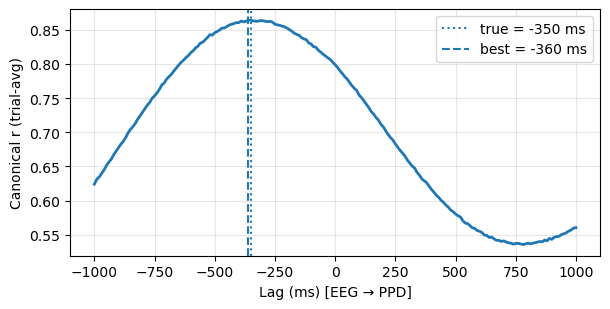

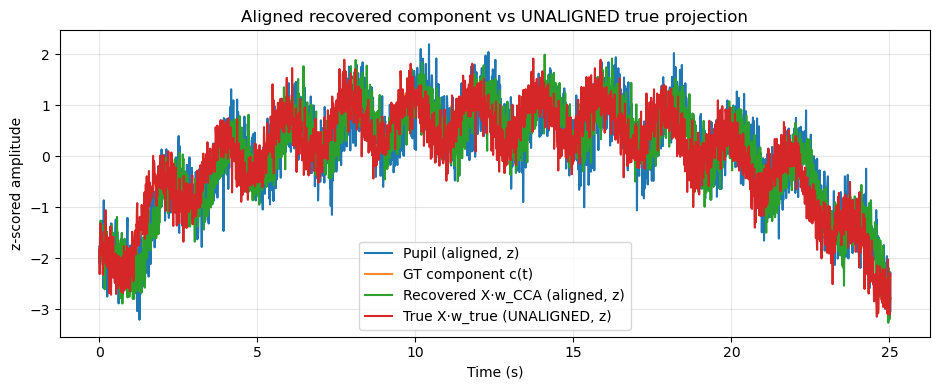

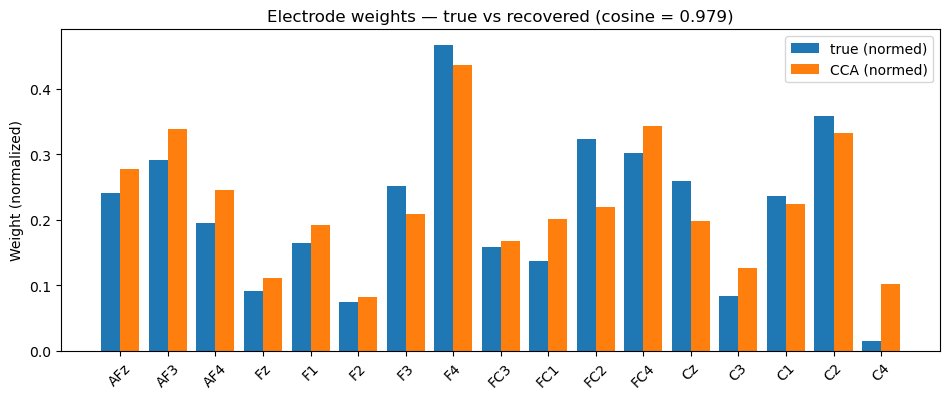

In [ ]:
# ======================= demo ========================
if __name__ == "__main__":
    TRUE_LAG_MS = -350
    trials = simulate_component_dataset_old(
        n_trials=12, trial_len_s=26.0,
        pupil_lag_ms=TRUE_LAG_MS,
        w_spread=0.7, eeg_noise_sd=0.3, eeg_crosstalk=0.3, pupil_noise_sd=0.4,
    )

    # After you simulate `trials` (before any concat/normalization):

    # 1) Component-projection SNR (one per trial)
    snr_comp = [snr_db_component_projection(tr) for tr in trials]

    # 2) Pupil SNR (use the same lag you used to generate y)
    snr_pup = [snr_db_pupil(tr, FS, TRUE_LAG_MS, trim_ms=300) for tr in trials]

    # 3) Channel-level SNRs (vector per trial). If you used eeg_crosstalk=0.10:
    LAM = 0.10
    snr_ch = [snr_db_channels(tr, crosstalk_lambda=LAM, treat_crosstalk_as_signal=False) for tr in trials]

    print(f"Component SNR (dB):  mean={np.mean(snr_comp):.2f}, median={np.median(snr_comp):.2f}")
    print(f"Pupil     SNR (dB):  mean={np.mean(snr_pup):.2f},  median={np.median(snr_pup):.2f}")
    print(f"Channel   SNR (dB):  median-of-medians={np.median([np.median(a) for a in snr_ch]):.2f}")


    # --- lag search (trial-wise aggregation so every trial has 1 vote) ---
    shifts = candidate_lags_units(step_ms=10, max_ms=1000)
    best_r, best_shift_samp, curve = search_best_lag(trials, shifts, trim_ms=300, return_curve=True)

    best_shift_ms = int(best_shift_samp*10)
    print(f"GT lag = {TRUE_LAG_MS} ms | recovered = {best_shift_ms} ms | r = {best_r:.3f}")

    # --- fit CCA once at best lag on all per-trial-normalized segments ---
    X_all, y_all = concat_trials(trials, shift_samples=best_shift_samp, trim_ms=300)
    cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
    cca.fit(X_all, y_all.reshape(-1,1))
    w_est = cca.x_weights_[:,0]
    w_est = w_est / (np.linalg.norm(w_est) if np.linalg.norm(w_est)>0 else 1.0)

    # --- compare weights (use trial 1's w_true as representative; they are same across sims) ---
    w_true = trials[0]['w_true']
    cos_sim = float(np.dot(w_true, w_est) / (np.linalg.norm(w_true)*np.linalg.norm(w_est)))
    print(f"Weight alignment (cosine) = {cos_sim:.3f}  (sign/scale are arbitrary)")

    # --- plot r vs lag ---
    xs = np.array(sorted(curve.keys()))*10
    ys = np.array([curve[k] for k in sorted(curve.keys())])
    plt.figure(figsize=(6.2,3.2))
    plt.plot(xs, ys, lw=2)
    plt.axvline(TRUE_LAG_MS, ls=':', label=f"true = {TRUE_LAG_MS} ms")
    plt.axvline(best_shift_ms, ls='--', label=f"best = {best_shift_ms} ms")
    plt.xlabel("Lag (ms) [EEG → PPD]")
    plt.ylabel("Canonical r (trial-avg)")
    plt.grid(alpha=.3); plt.legend(); plt.tight_layout()

    # --- pick one trial ---
    tr = trials[0]
    X1, y1, c1 = tr['X'], tr['y'], tr['c']
    s = best_shift_samp
    K = int(round(300/10))  # same trim as training

    # 1) Build the ALIGNED set (for recovered comp & pupil)
    X1_al, y1_al = align_by_shift_segment(X1, y1, s)
    X1_al, y1_al = X1_al[K:-K], y1_al[K:-K]
    X1_al = normalise_eeg(X1_al)
    y1_al = zscore1(y1_al)

    # Recovered component (aligned)
    c_rec = zscore1(X1_al @ w_est)

    # 2) Build the UNALIGNED set with the SAME LENGTH (no shift)
    #    Take the corresponding segment of X1 and c1 that matches the aligned length,
    #    but WITHOUT shifting them in time.
    Tmn = min(len(X1), len(y1))
    if s >= 0:
        # aligned kept X[:Tmn-s], so keep the same slice unshifted
        X1_un = X1[:Tmn - s]
        c1_un = c1[:Tmn - s]
    else:
        # aligned kept X[|s|:], so keep the same slice unshifted
        X1_un = X1[-s:]
        c1_un = c1[-s:]

    # apply the same trim K (but no alignment shift)
    X1_un = X1_un[K:-K]
    c1_un = c1_un[K:-K]

    # per-trial normalization for plotting consistency
    X1_un = normalise_eeg(X1_un)

    # True projection (UNALIGNED)
    w_true = tr['w_true']
    c_true_proj_un = zscore1(X1_un @ w_true)

    # 3) Plot
    t = np.arange(len(y1_al)) / FS
    plt.figure(figsize=(9.5,4.0))
    plt.plot(t, y1_al,            label="Pupil (aligned, z)")
    plt.plot(t, zscore1(c1_un),             label="GT component c(t)", alpha=.9)
    plt.plot(t, c_rec,            label="Recovered X·w_CCA (aligned, z)")
    plt.plot(t, c_true_proj_un,   label="True X·w_true (UNALIGNED, z)")
    # Optionally also show c_al if you want GT aligned view:
    # plt.plot(t, zscore1(c_al), label="GT c(t) (aligned, z)", ls="--")
    plt.xlabel("Time (s)"); plt.ylabel("z-scored amplitude")
    plt.title("Aligned recovered component vs UNALIGNED true projection")
    plt.grid(alpha=.3); plt.legend(); plt.tight_layout()


    # --- weights bar plot ---
    plt.figure(figsize=(9.6,4.1))
    idx = np.arange(N_CH)
    plt.bar(idx-0.2, w_true/np.linalg.norm(w_true), width=0.4, label="true (normed)")
    plt.bar(idx+0.2, w_est/np.linalg.norm(w_est),   width=0.4, label="CCA (normed)")
    plt.xticks(idx, FRONTAL_MIDLINE, rotation=45)
    plt.ylabel("Weight (normalized)"); 
    plt.title(f"Electrode weights — true vs recovered (cosine = {cos_sim:.3f})")
    plt.legend(); plt.tight_layout()
    plt.show()


## LEt's see how it differes with the number of trials
first gaussian noise, no components

In [ ]:
# ---------------- experiment: n_trials sweep ----------------
TRUE_LAG_MS = -350  # your convention: negative = delay

# Fix one GT weight vector across ALL runs so cos-sim is comparable
w0 = 1.0 + 0.7 * RNG.normal(size=N_CH)
w0 = w0 / (np.linalg.norm(w0) or 1.0)

trial_counts = [1] + list(range(10, 110, 10)) + list(range(125, 225, 25))

cos_sims = []
best_rs  = []
best_lags = []
anomalies = []  # (n_trials, best_r, best_shift_ms)

for n in trial_counts:
    trials = simulate_component_dataset_noise(
        n_trials=n, trial_len_s=26.0,
        pupil_lag_ms=TRUE_LAG_MS,
        w_spread=0.7, eeg_noise_sd=0.3, eeg_crosstalk=0.3, pupil_noise_sd=0.4,
        w_true_fixed=w0,  # keep same GT weights across runs
    )

    # 1) lag search on concatenated, per-trial-normalized data
    shifts = candidate_lags_units(step_ms=10, max_ms=1000)
    best_r, best_shift_samp, _ = search_best_lag(
        trials, shifts, trim_ms=300, return_curve=True
    )
    best_shift_ms = int(best_shift_samp * 10)

    # 2) fit CCA once at best lag and get weights
    X_all, y_all = concat_trials(trials, shift_samples=best_shift_samp, trim_ms=300)
    cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
    cca.fit(X_all, y_all.reshape(-1, 1))
    w_est = cca.x_weights_[:, 0]

    # cosine similarity (sign-agnostic)
    num = float(np.dot(w0, w_est))
    den = (np.linalg.norm(w0) or 1.0) * (np.linalg.norm(w_est) or 1.0)
    cs = abs(num / den)

    cos_sims.append(cs)
    best_rs.append(best_r)
    best_lags.append(best_shift_ms)

    if best_shift_ms != TRUE_LAG_MS:
        anomalies.append((n, best_r, best_shift_ms))

# ---- report anomalies ----
if anomalies:
    print("⚠️ Cases where recovered lag ≠ GT lag:")
    for n, r, lag in anomalies:
        print(f"  n_trials={n:3d}: best_r={r:.3f}, best_shift_ms={lag} (GT {TRUE_LAG_MS})")
else:
    print("✅ All recovered lags matched the ground-truth.")

# ---- plot: cos_sim vs n_trials ----
plt.figure(figsize=(6.4, 3.4))
plt.plot(trial_counts, cos_sims, marker='o', lw=1.8)
plt.ylim(0.0, 1.02)
plt.xlabel("Number of trials")
plt.ylabel("Cosine(w_true, w_est)")
plt.title("Weight recovery vs number of trials")
plt.grid(alpha=.3)
plt.tight_layout()

# ---- plot: best_r vs n_trials ----
plt.figure(figsize=(6.4, 3.4))
plt.plot(trial_counts, best_rs, marker='o', lw=1.8)
plt.ylim(0.0, 1.02)
plt.xlabel("Number of trials")
plt.ylabel("Best canonical r")
plt.title("Best CCA correlation vs number of trials")
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()


In [ ]:
# ---- lag error (signed and absolute) vs number of trials ----
best_lags = np.asarray(best_lags)
trial_counts_arr = np.asarray(trial_counts)

lag_err_signed = best_lags - TRUE_LAG_MS         # in ms (signed)
lag_err_abs    = np.abs(lag_err_signed)          # in ms (absolute)

# quick text summary
n_off = int(np.sum(lag_err_abs != 0))
print(f"\nLag errors: mean={lag_err_signed.mean():.1f} ms (signed), "
      f"median={np.median(lag_err_signed):.1f} ms, "
      f"mean|err|={lag_err_abs.mean():.1f} ms.  "
      f"Off-by-step cases: {n_off}/{len(trial_counts_arr)}")

# plot signed error
plt.figure(figsize=(6.4, 3.4))
plt.axhline(0, color='k', lw=1, ls='--', alpha=0.6)
plt.plot(trial_counts_arr, lag_err_signed, marker='o', lw=1.8)
plt.xlabel("Number of trials")
plt.ylabel("Lag error (ms) = best_lag − TRUE_LAG_MS")
plt.title("Lag error vs number of trials (signed)")
plt.grid(alpha=.3)
plt.tight_layout()

# plot absolute error
plt.figure(figsize=(6.4, 3.4))
plt.plot(trial_counts_arr, lag_err_abs, marker='o', lw=1.8)
plt.xlabel("Number of trials")
plt.ylabel("Absolute lag error (ms)")
plt.title("Absolute lag error vs number of trials")
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()


## WHAT IF WE DEVIDE INTO SLOW/FAST COMPONENT?

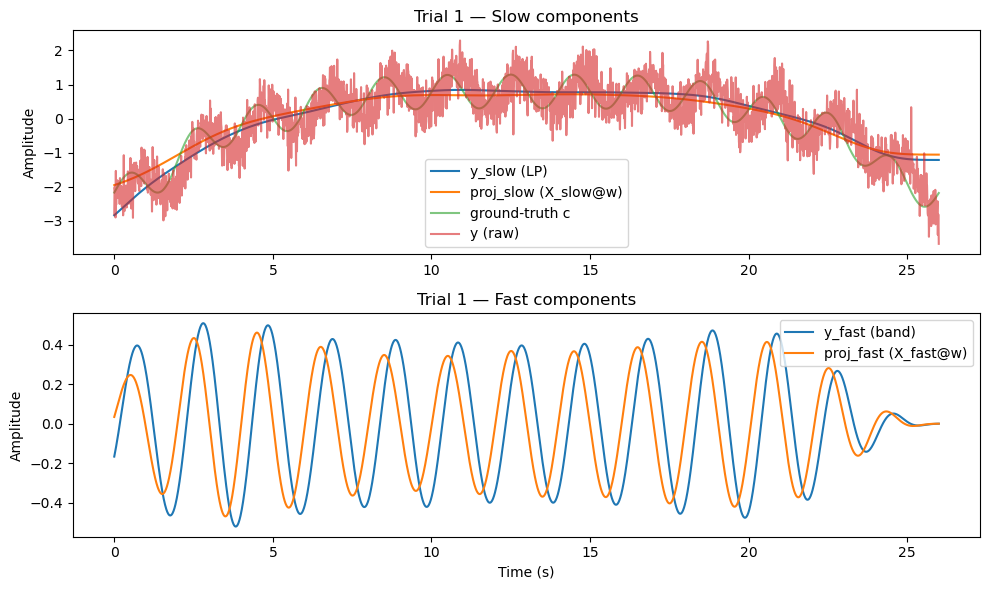

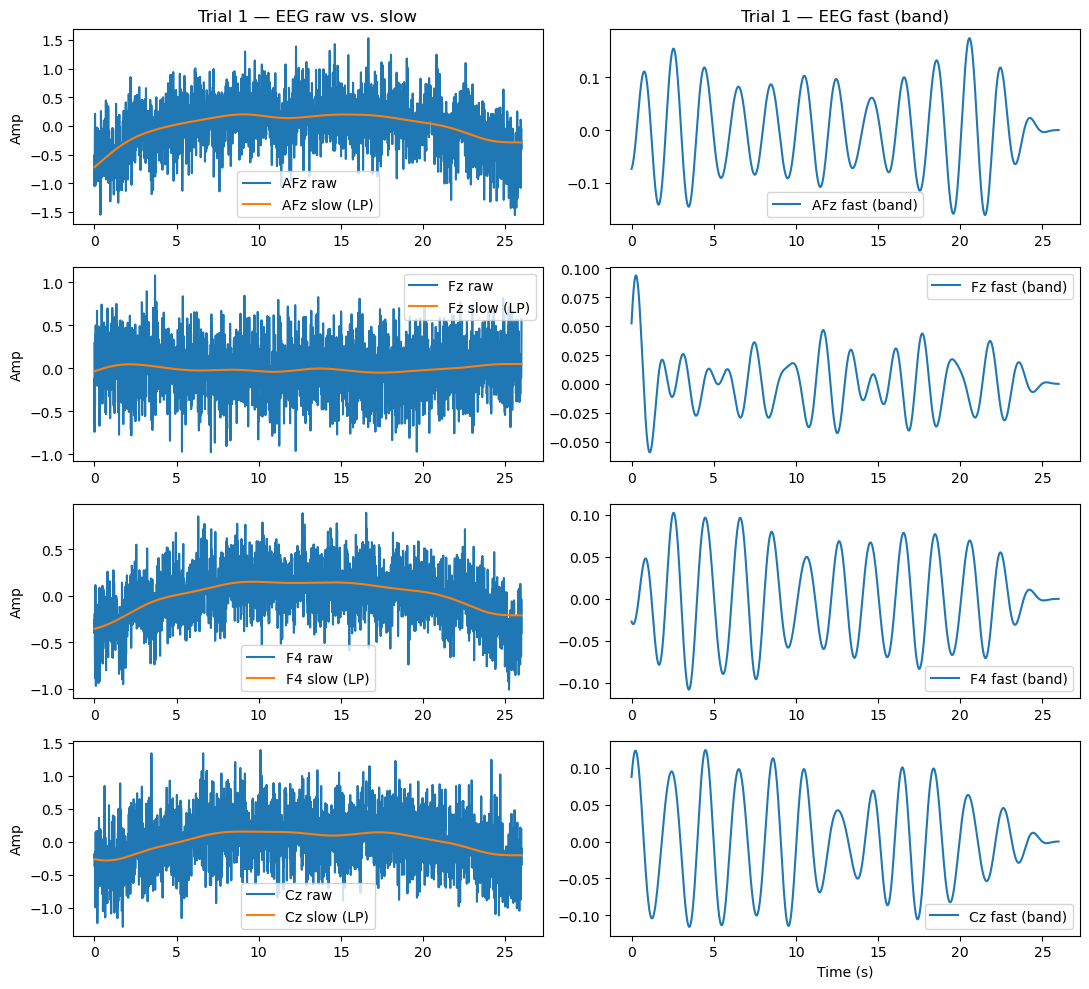

PearsonRResult(statistic=0.8142834615351799, pvalue=0.0)
PearsonRResult(statistic=0.9876333780231951, pvalue=0.0)
PearsonRResult(statistic=0.4583310918336574, pvalue=0.0)


In [59]:
TRUE_LAG_MS = -350
trials = simulate_component_dataset_old(
    n_trials=12, trial_len_s=26.0,
    pupil_lag_ms=TRUE_LAG_MS,
    w_spread=0.7, eeg_noise_sd=0.3, eeg_crosstalk=0.3, pupil_noise_sd=0.4,
)
FS = 100  # or whatever you used in the simulator
trials_with_comp = split_components_all_trials(trials, fs=FS, low_fc=0.25, band=(0.4, 0.7))

plot_y_vs_proj_components(trials_with_comp[0], fs=FS, title_prefix="Trial 1")
plot_X_components(trials_with_comp[0], fs=FS, ch_idx=(0,3,7,12), ch_names=FRONTAL_MIDLINE, title_prefix="Trial 1")


all_y_slow = np.concatenate([trial['y_slow'] for trial in trials_with_comp])
all_X_slow = np.concatenate([trial['X_slow'] for trial in trials_with_comp])
all_y_fast = np.concatenate([trial['y_fast'] for trial in trials_with_comp])
all_X_fast = np.concatenate([trial['X_fast'] for trial in trials_with_comp])
all_y = np.concatenate([trial['y'] for trial in trials_with_comp])
all_X = np.concatenate([trial['X'] for trial in trials_with_comp])
print(pearsonr(all_y, all_X @ trials_with_comp[0]['w_true']))
print(pearsonr(all_y_slow, all_X_slow @ trials_with_comp[0]['w_true']))
print(pearsonr(all_y_fast, all_X_fast @ trials_with_comp[0]['w_true']))

## TRY DIFFERENT NOISE (NOT GAUSSIAN)
The slow component is almost identical with only gaussian noise

In [82]:
w0 = 1.0 + 0.7 * RNG.normal(size=N_CH)
w0 = w0 / (np.linalg.norm(w0) or 1.0)

TRUE_LAG_MS = -350
trials_gauss = simulate_component_dataset_noise(w_true_fixed=w0, pupil_extra=None, pupil_lag_ms=TRUE_LAG_MS)
#trials_ar1 = simulate_component_dataset_noise(w_true_fixed=w0, pupil_extra='ar1', pupil_extra_scale=0.6, pupil_lag_ms=TRUE_LAG_MS)
#trials_LagJit = simulate_component_dataset_noise(w_true_fixed=w0, lag_jitter_ms=abs(TRUE_LAG_MS)*0.25, pupil_lag_ms=TRUE_LAG_MS)
#trials_eegDrift_pupNonLin = simulate_component_dataset_noise(eeg_weight_drift=True, eeg_noise_sd=0.2, pupil_nonlinear=True, w_true_fixed=w0, pupil_lag_ms=TRUE_LAG_MS)
#trialsPink_Jit = simulate_component_dataset_noise(w_true_fixed=w0, pupil_extra='pink', pupil_extra_scale=0.5, lag_jitter_ms=abs(TRUE_LAG_MS)*0.25, pupil_lag_ms=TRUE_LAG_MS)

trials_noise = simulate_component_dataset_noise(w_true_fixed=w0, pupil_extra='ar1', pupil_extra_scale=0.5,
                                                lag_jitter_ms=abs(TRUE_LAG_MS)*0.25,
                                                eeg_weight_drift=True, eeg_noise_sd=0.2, pupil_lag_ms=TRUE_LAG_MS)

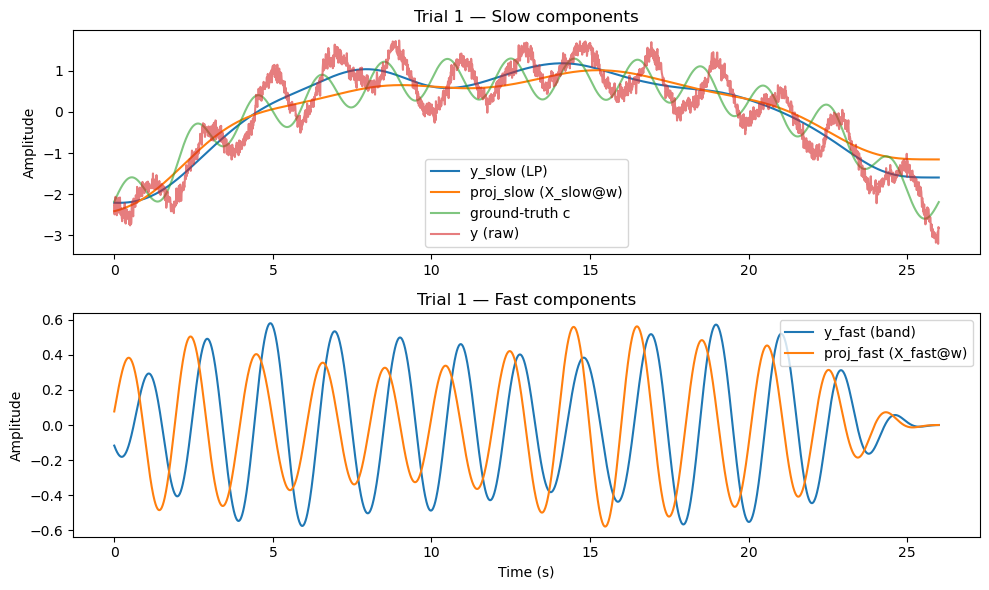

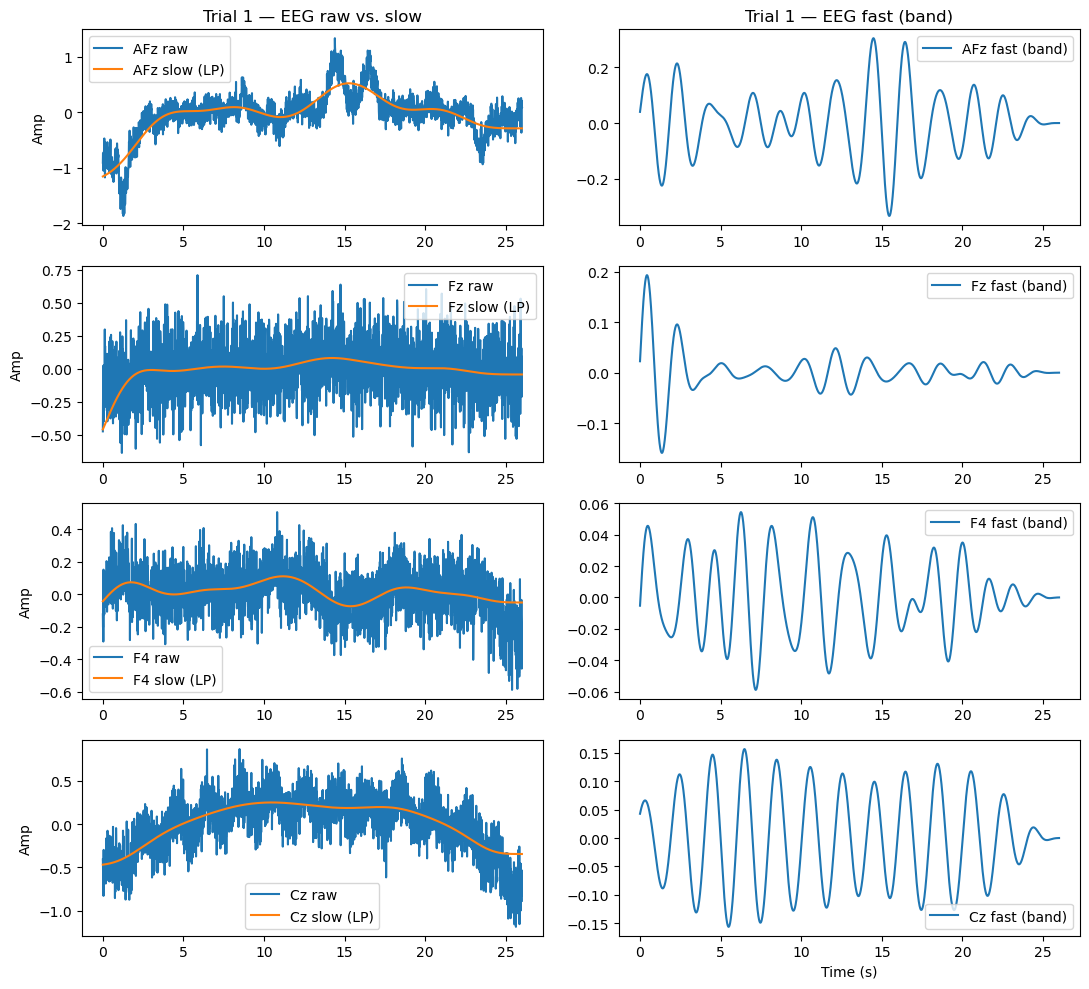

PearsonRResult(statistic=0.8468846302077799, pvalue=0.0)
PearsonRResult(statistic=0.9460902090050406, pvalue=0.0)
PearsonRResult(statistic=0.4243385683474921, pvalue=0.0)


In [120]:
trials_with_comp = split_components_all_trials(trials_noise, fs=FS, low_fc=0.25, band=(0.4, 0.7))
plot_y_vs_proj_components(trials_with_comp[0], fs=FS, title_prefix="Trial 1")
plot_X_components(trials_with_comp[0], fs=FS, ch_idx=(0,3,7,12), ch_names=FRONTAL_MIDLINE, title_prefix="Trial 1")


all_y_slow = np.concatenate([trial['y_slow'] for trial in trials_with_comp])
all_X_slow = np.concatenate([trial['X_slow'] for trial in trials_with_comp])
all_y_fast = np.concatenate([trial['y_fast'] for trial in trials_with_comp])
all_X_fast = np.concatenate([trial['X_fast'] for trial in trials_with_comp])
all_y = np.concatenate([trial['y'] for trial in trials_with_comp])
all_X = np.concatenate([trial['X'] for trial in trials_with_comp])
print(pearsonr(all_y, all_X @ trials_with_comp[0]['w_true']))
print(pearsonr(all_y_slow, all_X_slow @ trials_with_comp[0]['w_true']))
print(pearsonr(all_y_fast, all_X_fast @ trials_with_comp[0]['w_true']))


=== MODE: slow ===
GT lag = -350 ms | recovered = -220 ms | r = 0.955
Final CCA correlation on all data: r = 0.955, p = 0.000e+00
Weight alignment (cosine) = 0.425  (sign/scale are arbitrary)


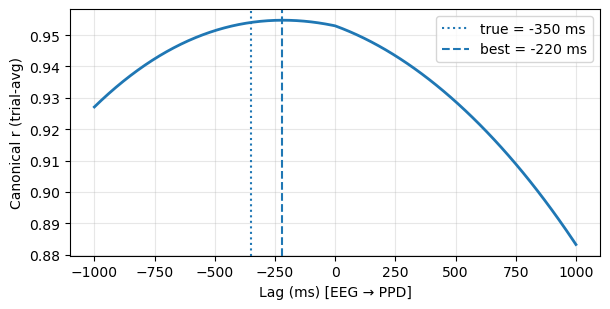

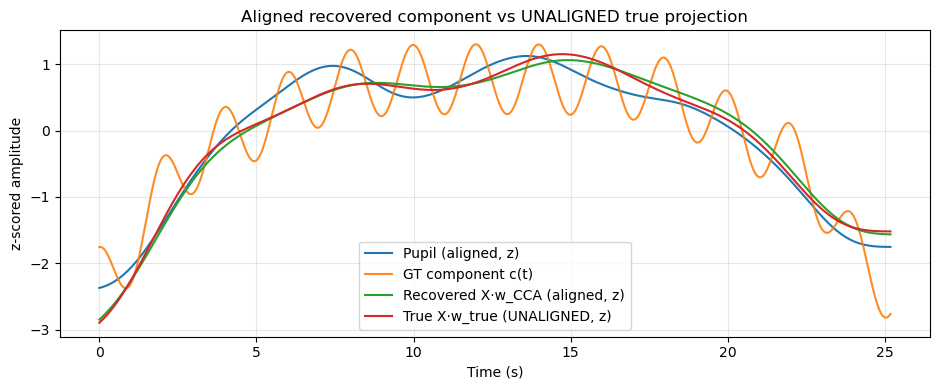

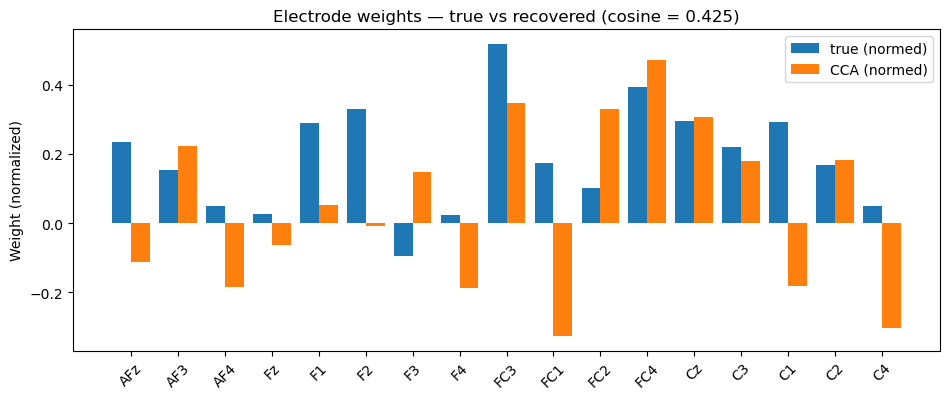


=== MODE: fast ===
GT lag = -350 ms | recovered = -350 ms | r = 0.957
Final CCA correlation on all data: r = 0.957, p = 0.000e+00
Weight alignment (cosine) = 0.603  (sign/scale are arbitrary)


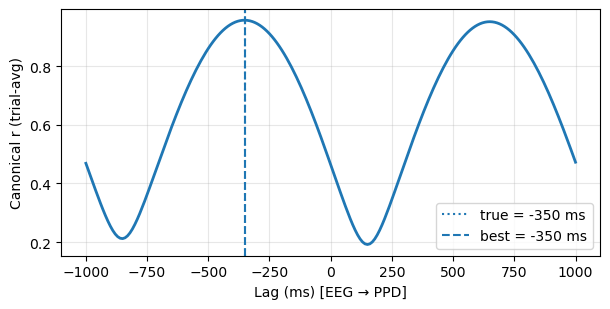

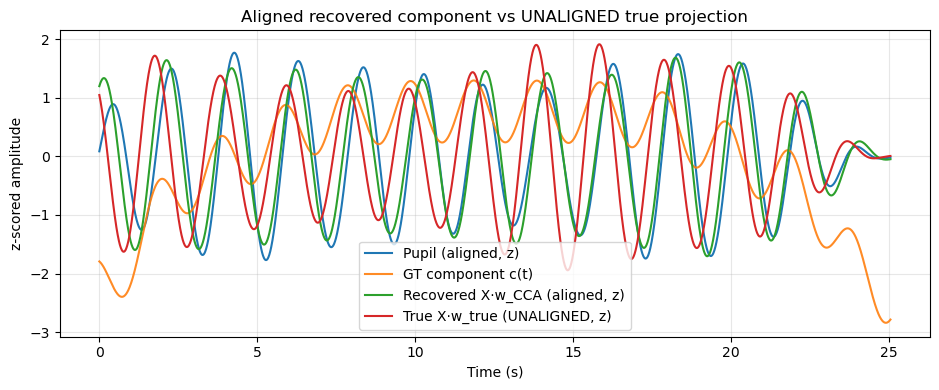

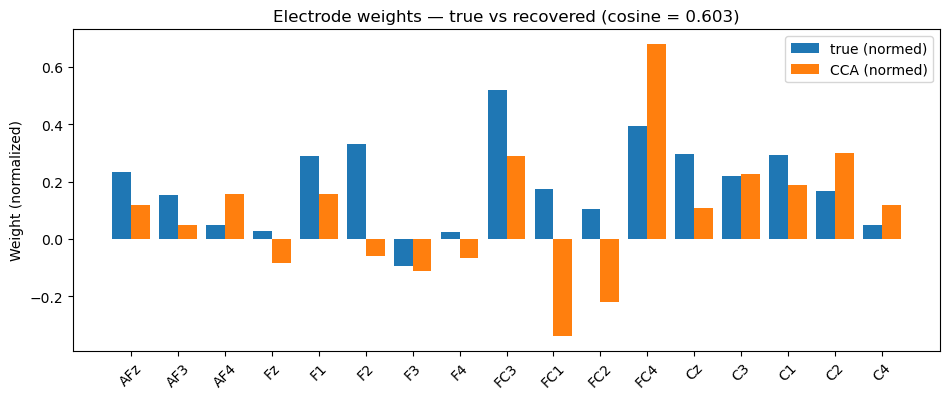


=== MODE: all ===
GT lag = -350 ms | recovered = -340 ms | r = 0.911
Final CCA correlation on all data: r = 0.911, p = 0.000e+00
Weight alignment (cosine) = 0.942  (sign/scale are arbitrary)


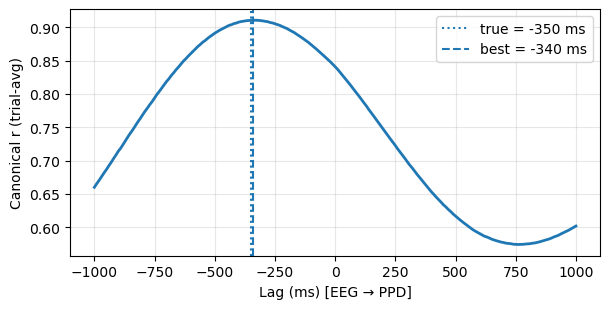

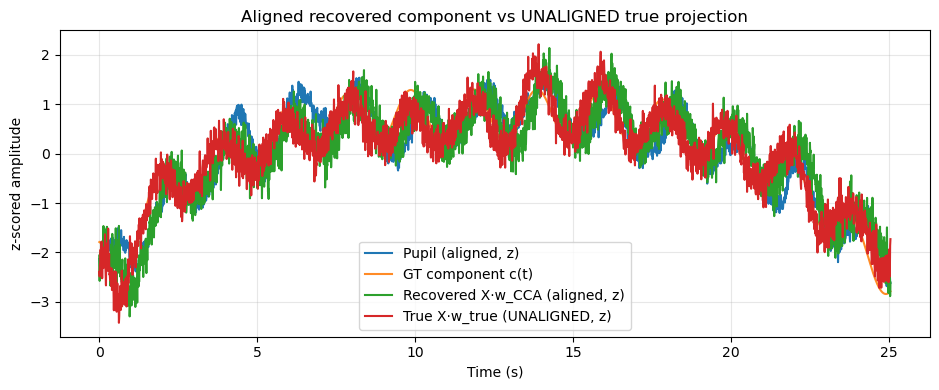

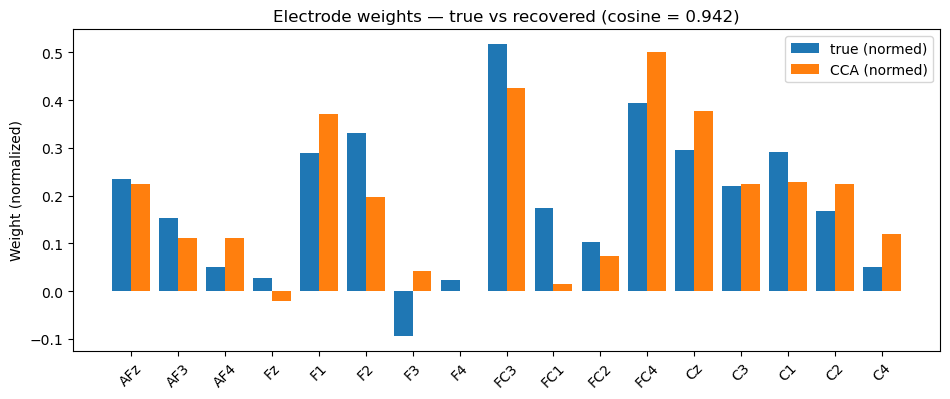

In [115]:
modes = ["slow", "fast", "all"]
trials_gauss = simulate_component_dataset_noise(n_trials=30, w_true_fixed=w0, pupil_extra=None, pupil_lag_ms=TRUE_LAG_MS)

trials_noise = simulate_component_dataset_noise(w_true_fixed=w0, pupil_extra='ar1', pupil_extra_scale=0.3,
                                                lag_jitter_ms=abs(TRUE_LAG_MS)*0.25, n_trials=12,
                                                eeg_weight_drift=True, eeg_noise_sd=0.2, pupil_lag_ms=TRUE_LAG_MS)
trials_og = trials_noise.copy()
trials_comp = split_components_all_trials(trials_og, fs=FS, low_fc=0.25, band=(0.4, 0.7))

for mode in modes:
    print(f"\n=== MODE: {mode} ===")
     # select data according to mode

    if mode == "slow":
        trials = [{'X': tr['X_slow'], 'y': tr['y_slow'], 'w_true': tr['w_true'], 'c': tr['c']} for tr in trials_comp]
    elif mode == "fast":
        trials = [{'X': tr['X_fast'], 'y': tr['y_fast'], 'w_true': tr['w_true'], 'c': tr['c']} for tr in trials_comp]
    else:
        trials = trials_og


    shifts = candidate_lags_units(step_ms=10, max_ms=1000)
    best_r, best_shift_samp, curve = search_best_lag(trials, shifts, trim_ms=300, return_curve=True)

    best_shift_ms = int(best_shift_samp*10)
    print(f"GT lag = {TRUE_LAG_MS} ms | recovered = {best_shift_ms} ms | r = {best_r:.3f}")

    # --- fit CCA once at best lag on all per-trial-normalized segments ---
    X_all, y_all = concat_trials(trials, shift_samples=best_shift_samp, trim_ms=300)
    cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
    cca.fit(X_all, y_all.reshape(-1,1))
    w_est = cca.x_weights_[:,0]
    w_y = round(cca.y_weights_[:, 0][0])
    if w_y != 1:
        if w_y != -1:
            raise ValueError("Unexpected pupil weight sign.")
        w_est = w_est / w_y  # make sure pupil weight is +1
    w_est = w_est / (np.linalg.norm(w_est) if np.linalg.norm(w_est)>0 else 1.0)

    final_corr = pearsonr(X_all @ w_est, y_all)
    print(f"Final CCA correlation on all data: r = {final_corr[0]:.3f}, p = {final_corr[1]:.3e}")

    # --- compare weights (use trial 1's w_true as representative; they are same across sims) ---
    w_true = trials[0]['w_true']
    cos_sim = float(np.dot(w_true, w_est) / (np.linalg.norm(w_true)*np.linalg.norm(w_est)))
    print(f"Weight alignment (cosine) = {cos_sim:.3f}  (sign/scale are arbitrary)")

    # --- plot r vs lag ---
    xs = np.array(sorted(curve.keys()))*10
    ys = np.array([curve[k] for k in sorted(curve.keys())])
    plt.figure(figsize=(6.2,3.2))
    plt.plot(xs, ys, lw=2)
    plt.axvline(TRUE_LAG_MS, ls=':', label=f"true = {TRUE_LAG_MS} ms")
    plt.axvline(best_shift_ms, ls='--', label=f"best = {best_shift_ms} ms")
    plt.xlabel("Lag (ms) [EEG → PPD]")
    plt.ylabel("Canonical r (trial-avg)")
    plt.grid(alpha=.3); plt.legend(); plt.tight_layout()

    # --- pick one trial ---
    tr = trials[0]
    X1, y1, c1 = tr['X'], tr['y'], tr['c']
    s = best_shift_samp
    K = int(round(300/10))  # same trim as training

    # 1) Build the ALIGNED set (for recovered comp & pupil)
    X1_al, y1_al = align_by_shift_segment(X1, y1, s)
    X1_al, y1_al = X1_al[K:-K], y1_al[K:-K]
    X1_al = normalise_eeg(X1_al)
    y1_al = zscore1(y1_al)

    # Recovered component (aligned)
    c_rec = zscore1(X1_al @ w_est)

    # 2) Build the UNALIGNED set with the SAME LENGTH (no shift)
    #    Take the corresponding segment of X1 and c1 that matches the aligned length,
    #    but WITHOUT shifting them in time.
    Tmn = min(len(X1), len(y1))
    if s >= 0:
        # aligned kept X[:Tmn-s], so keep the same slice unshifted
        X1_un = X1[:Tmn - s]
        c1_un = c1[:Tmn - s]
    else:
        # aligned kept X[|s|:], so keep the same slice unshifted
        X1_un = X1[-s:]
        c1_un = c1[-s:]

    # apply the same trim K (but no alignment shift)
    X1_un = X1_un[K:-K]
    c1_un = c1_un[K:-K]

    # per-trial normalization for plotting consistency
    X1_un = normalise_eeg(X1_un)

    # True projection (UNALIGNED)
    w_true = tr['w_true']
    c_true_proj_un = zscore1(X1_un @ w_true)

    # 3) Plot
    t = np.arange(len(y1_al)) / FS
    plt.figure(figsize=(9.5,4.0))
    plt.plot(t, y1_al,            label="Pupil (aligned, z)")
    plt.plot(t, zscore1(c1_un),             label="GT component c(t)", alpha=.9)
    plt.plot(t, c_rec,            label="Recovered X·w_CCA (aligned, z)")
    plt.plot(t, c_true_proj_un,   label="True X·w_true (UNALIGNED, z)")
    # Optionally also show c_al if you want GT aligned view:
    # plt.plot(t, zscore1(c_al), label="GT c(t) (aligned, z)", ls="--")
    plt.xlabel("Time (s)"); plt.ylabel("z-scored amplitude")
    plt.title("Aligned recovered component vs UNALIGNED true projection")
    plt.grid(alpha=.3); plt.legend(); plt.tight_layout()


    # --- weights bar plot ---
    plt.figure(figsize=(9.6,4.1))
    idx = np.arange(N_CH)
    plt.bar(idx-0.2, w_true/np.linalg.norm(w_true), width=0.4, label="true (normed)")
    plt.bar(idx+0.2, w_est/np.linalg.norm(w_est),   width=0.4, label="CCA (normed)")
    plt.xticks(idx, FRONTAL_MIDLINE, rotation=45)
    plt.ylabel("Weight (normalized)"); 
    plt.title(f"Electrode weights — true vs recovered (cosine = {cos_sim:.3f})")
    plt.legend(); plt.tight_layout()
    plt.show()

Let's see how the number of trials affects the correlation, cosine similarity and lag

In [119]:
import numpy as np
from sklearn.cross_decomposition import CCA

# --------- CONFIG ---------
REPEATS = 10
N_TRIALS_LIST = [12, 36, 100]
MODES = ["slow", "fast", "all"]
STEP_MS = 10
TRIM_MS = 300

# noise settings = your current "trials_noise" config
def make_trials_og(n_trials):
    return simulate_component_dataset_noise(
        w_true_fixed=w0,
        pupil_extra='ar1',
        pupil_extra_scale=0.3,
        lag_jitter_ms=int(abs(TRUE_LAG_MS) * 0.25),
        n_trials=n_trials,
        eeg_weight_drift=True,
        eeg_noise_sd=0.2,
        pupil_lag_ms=TRUE_LAG_MS
    )

def make_trials_for_mode(trials_comp, trials_og, mode):
    if mode == "slow":
        return [{'X': tr['X_slow'], 'y': tr['y_slow'], 'w_true': tr['w_true'], 'c': tr['c']} for tr in trials_comp]
    elif mode == "fast":
        return [{'X': tr['X_fast'], 'y': tr['y_fast'], 'w_true': tr['w_true'], 'c': tr['c']} for tr in trials_comp]
    else:
        return trials_og

def run_once(n_trials, mode):
    # simulate
    trials_og   = make_trials_og(n_trials)
    trials_comp = split_components_all_trials(trials_og, fs=FS, low_fc=0.25, band=(0.4, 0.7))
    trials      = make_trials_for_mode(trials_comp, trials_og, mode)

    # sweep lag (sign-invariant inside your search_best_lag if you adopted abs; otherwise it still works)
    shifts = candidate_lags_units(step_ms=STEP_MS, max_ms=1000)
    best_r, best_shift_samp, _ = search_best_lag(trials, shifts, trim_ms=TRIM_MS, return_curve=True)
    best_shift_ms = int(best_shift_samp * STEP_MS)

    # fit CCA at best lag
    X_all, y_all = concat_trials(trials, shift_samples=best_shift_samp, trim_ms=TRIM_MS)
    cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
    cca.fit(X_all, y_all.reshape(-1, 1))

    # canonical correlation (nonnegative by construction)
    U, V = cca.transform(X_all, y_all.reshape(-1, 1))
    r_can = float(np.corrcoef(U[:, 0], V[:, 0])[0, 1])

    # X-side weights and alignment
    w_est = cca.x_weights_[:, 0]
    w_est = w_est / (np.linalg.norm(w_est) or 1.0)
    w_true = trials[0]['w_true']
    cos_sim = float(np.dot(w_true, w_est) / ((np.linalg.norm(w_true) or 1.0)*(np.linalg.norm(w_est) or 1.0)))
    cos_sim_abs = abs(cos_sim)  # sign is arbitrary; use magnitude for averaging

    # lag errors
    lag_err_signed = best_shift_ms - TRUE_LAG_MS
    lag_err_abs = abs(lag_err_signed)

    return dict(r_can=r_can, cos_abs=cos_sim_abs, lag_err=lag_err_signed, lag_abs=lag_err_abs)

# --------- RUN & AGGREGATE ---------
results = {n: {m: {'r_can': [], 'cos_abs': [], 'lag_err': [], 'lag_abs': []}
               for m in MODES}
           for n in N_TRIALS_LIST}

for n_trials in N_TRIALS_LIST:
    for rep in range(REPEATS):
        # fresh RNG per repeat if you want repeat variability; otherwise reuse your global RNG
        for mode in MODES:
            out = run_once(n_trials, mode)
            for k in results[n_trials][mode]:
                results[n_trials][mode][k].append(out[k])

# --------- SUMMARY PRINT ---------
def mean_std(x):
    x = np.asarray(x, float)
    return float(np.mean(x)), float(np.std(x, ddof=1)) if len(x) > 1 else 0.0

for n_trials in N_TRIALS_LIST:
    print(f"\n================  n_trials = {n_trials}  ================")
    for mode in MODES:
        r_m, r_s   = mean_std(results[n_trials][mode]['r_can'])
        c_m, c_s   = mean_std(results[n_trials][mode]['cos_abs'])
        de_m, de_s = mean_std(results[n_trials][mode]['lag_err'])
        ae_m, ae_s = mean_std(results[n_trials][mode]['lag_abs'])
        print(f"[{mode:5s}]  r_can = {r_m:.3f} ± {r_s:.3f} | "
              f"|cos| = {c_m:.3f} ± {c_s:.3f} | "
              f"lag_err(ms) = {de_m:+.1f} ± {de_s:.1f} | "
              f"|lag_err|(ms) = {ae_m:.1f} ± {ae_s:.1f}")



================  n_trials = 12  ================
[slow ]  r_can = 0.963 ± 0.003 | |cos| = 0.363 ± 0.126 | lag_err(ms) = +105.0 ± 153.4 | |lag_err|(ms) = 149.0 ± 105.4
[fast ]  r_can = 0.958 ± 0.004 | |cos| = 0.552 ± 0.056 | lag_err(ms) = +202.0 ± 420.9 | |lag_err|(ms) = 212.0 ± 415.4
[all  ]  r_can = 0.908 ± 0.007 | |cos| = 0.904 ± 0.040 | lag_err(ms) = +13.0 ± 17.0 | |lag_err|(ms) = 17.0 ± 12.5

================  n_trials = 36  ================
[slow ]  r_can = 0.953 ± 0.003 | |cos| = 0.736 ± 0.073 | lag_err(ms) = +96.0 ± 71.1 | |lag_err|(ms) = 96.0 ± 71.1
[fast ]  r_can = 0.940 ± 0.007 | |cos| = 0.775 ± 0.049 | lag_err(ms) = +1.0 ± 11.0 | |lag_err|(ms) = 7.0 ± 8.2
[all  ]  r_can = 0.899 ± 0.005 | |cos| = 0.950 ± 0.016 | lag_err(ms) = +13.0 ± 17.7 | |lag_err|(ms) = 17.0 ± 13.4

================  n_trials = 100  ================
[slow ]  r_can = 0.947 ± 0.003 | |cos| = 0.891 ± 0.044 | lag_err(ms) = +74.0 ± 23.2 | |lag_err|(ms) = 74.0 ± 23.2
[fast ]  r_can = 0.932 ± 0.004 | |cos| = 0.